# Beyond Pace: Pace-Driven Running vs Navigation-Driven Sports

### Part 2 - Exploratory Data Analysis (EDA)

---

In this notebook we explore the cleaned combined dataset from Part 1.

The goal is to understand how key training metrics - distance, pace, heart rate and elevation — differ between navigation-driven and pace-driven athlete profiles, and whether standard running metrics can fully describe navigation-driven sports.


We work through 10 research questions using visualizations, aggregations, and a summary pivot table.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\viver\AppData\Local\Temp\ipykernel_9844\687462750.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# завантажуємо підготовлений датасет

df_combined = pd.read_csv("../data/processed/garmin_combined.csv")

In [3]:
df_combined.head()

,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Aerobic TE,...,Avg Power,Max Power,Grit,Flow,Total Strokes,Avg. Swolf,Avg Stroke Rate,Body Battery Drain,Min Temp,Max Temp
0,Trail Running,2026-05-17 11:56:00,False,"🦊3,5 training",8.38,479.0,01:06:42,151.0,187.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Trail Running,2026-05-16 14:20:24,False,"🦊3,5 training",9.64,607.0,01:49:50,139.0,183.0,3.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Trail Running,2026-05-09 11:45:01,False,🦊 144 training,10.90,740.0,02:31:34,130.0,175.0,3.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Trail Running,2026-05-03 10:16:03,False,Lutskyi raion Running,4.53,299.0,00:49:57,136.0,174.0,2.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Trail Running,2026-05-02 12:04:59,False,"🦊ARDF, ЧУ 3,5, Луцьк",11.35,617.0,01:54:51,141.0,186.0,3.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# після read_csv Date тип знову став object, переводимо
df_combined["Date"] = pd.to_datetime(df_combined["Date"])

---
### EDA

#### 1. How does the distribution of activity distances differ between navigation-driven and pace-driven athletes?

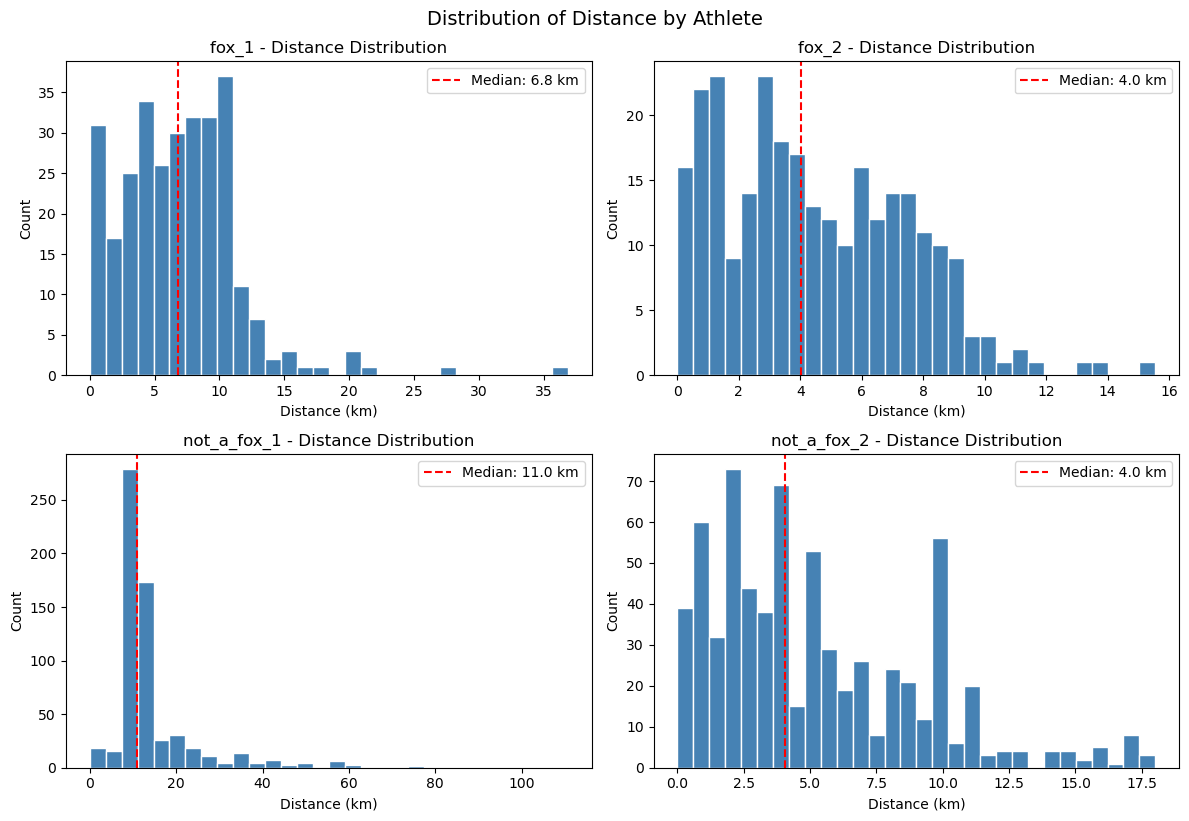

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
athletes = df_combined["Athlete"].unique()

for i in range(4):
    ax = axes.flat[i]          # axes.flat перетворює сітку 2x2 в плоский список [ax0, ax1, ax2, ax3]
    athlete = athletes[i]

    data = df_combined[df_combined["Athlete"] == athlete]["Distance"].dropna()
    ax.hist(data, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"{athlete} - Distance Distribution")
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Count")
    ax.axvline(data.median(), color="red", linestyle="--", label=f"Median: {data.median():.1f} km")  # червоний пунктир на медіані
    ax.legend()

plt.tight_layout()
plt.suptitle("Distribution of Distance by Athlete", y=1.02, fontsize=14)

plt.savefig("../images/Distribution_of_Distance.png", dpi=300, bbox_inches="tight")
plt.show()

З гістограми видно відсутність спільного патерну між 4 атлетама, і навіть окремо за видом активності не проглядається схожості для navigation-driven чи pace-driven athletes.
Всі мають різну медіану дистанцій, і свою шкала кілометражу, яка схожа лише для fox_2 та not_a_fox_2.

Тобто, розподіл дистанції не є визначальною характеристикою певного виду активності, скоріше це особливість activity profile кожного спортсмена.

---

#### 2. How does average pace differ between athlete profiles?

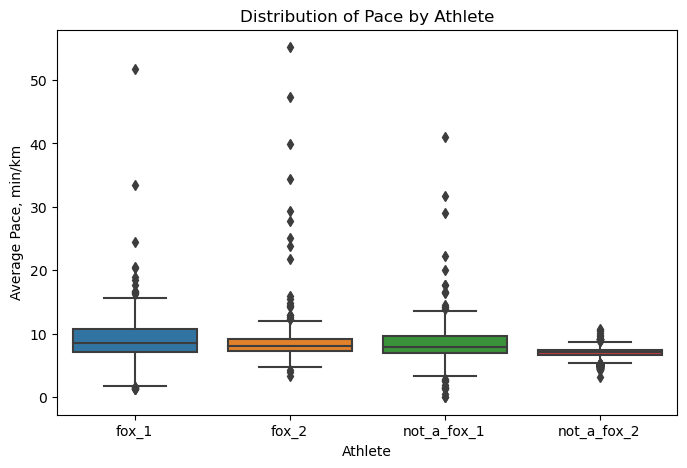

In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(data = df_combined, 
            x="Athlete", 
            y="Avg Pace num"

)
plt.title("Distribution of Pace by Athlete")
plt.xlabel("Athlete")
plt.ylabel("Average Pace, min/km")

plt.savefig("../images/Distribution_of_Pace.png", dpi=300, bbox_inches="tight")
plt.show()

Боксплот відображає Average Pace - це середній темп, він показує, скільки хвилин спортсмен витрачав на 1 км. Менше значення означає швидший рух. Але для орієнтування та ARDF темп не можна трактувати лише як фізичну швидкість, бо на нього сильно впливають навігація, рельєф і складність дистанції.

Як видно - середній темп всіх спортсменів приблизно однаковий. Різняться його діапазони у кожного. 
Цікаво, що not_a_fox_2 немає навіть викидів, його темп дуже стабільний!
Решта атлетів мають довгі хвости - їх темп переважно тримається в рамках вузького діапазону, але часто переривається аж до повної зупинку. Це є типовим патерном для navigation-driven спорту. А от викиди для not_a_fox_1 потребують додаткової інформації для пояснення.

Отже, Average Pace в профайлі спортсмена дійсно вказує тип його активності. Як? Pace-driven athletes following a fixed, clearly marked track - тому їх тмп буде максимально стабільним, хай навіть матиме ширший діапазон. А для navigation-driven спортсменів не існує прокладених шляхів, вони буквально продираються крізь ліси, оврагі, болота -темп змінюється постійно і непердбачувано.

---

#### 3. How does average heart rate differ across navigation-driven athletes and a pace-driven runners?

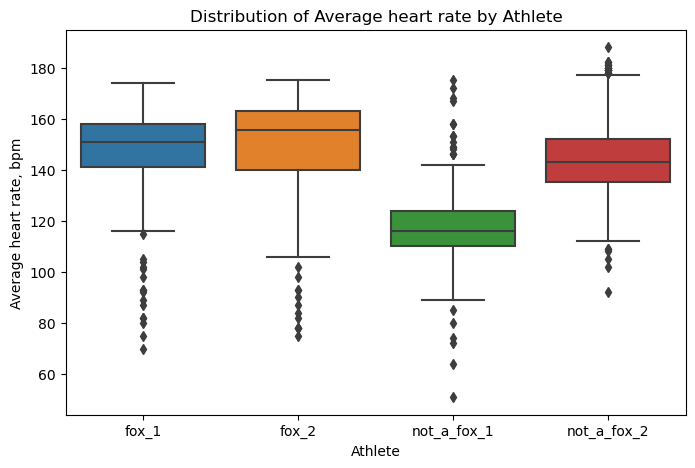

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(data = df_combined, 
            x="Athlete", 
            y="Avg HR"

)
plt.title("Distribution of Average heart rate by Athlete")
plt.xlabel("Athlete")
plt.ylabel("Average heart rate, bpm")

plt.savefig("../images/Distribution_of_HR.png", dpi=300, bbox_inches="tight")
plt.show()

Розподіл середніх показників серцебиття для fox_1 та fox_2 незначно відрізняється, хоч fox_2 має трохи ширший діапазон значень, і not_a_fox_2  показує меншу сереню частоту серцебиття і хвости рівномірно як в більшу так і в меншу сторони. А от профіль not_a_fox_1 сильно вирізняється. Його Avg HR значно нижче за інших спортсменів, хоча і має верхні викиди до рівня решти. Можливо це повязано зі спокійним темпом, відсутністю висот, а можливо це персональна особливість.

Avg HR для fox_1 та fox_2 мають викиди тільки вниз (80-100 уд/хв) - це не відпочинок, як могло б здатись, а саме специфіка Navigation Driven спорту, де є періоди простого подолання деяких ділянок, і окремі етапи "набігання" (прискорення), або навпаки уповільнення, видряпатись на підйом, перейти заболоченість тощо.

Тобто, на цьому гафіку ми побачили ще одну особливість Navigation-driven athletes, яка захована в даних. Вони працюють в зоні наближеній до максимального серцебиття, але в сили обставин і нюансів спорту - мають раптові спольнення, які відображаються тут викидами.

---

#### 4. How does elevation gain differ across athlete profiles — and what does it reveal about terrain and decision-making?

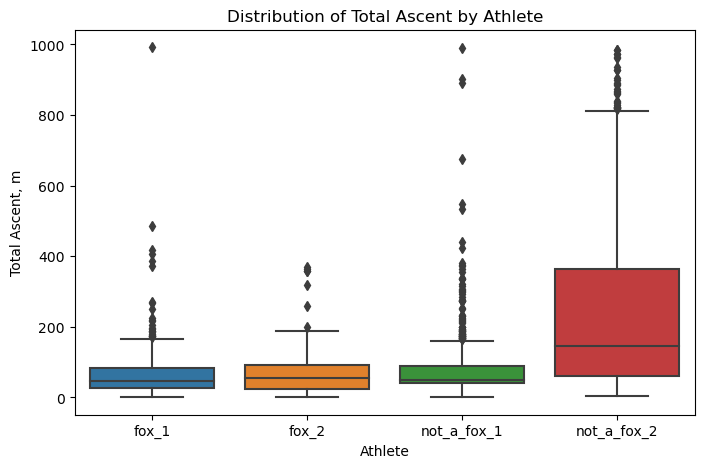

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(data = df_combined, 
            x="Athlete", 
            y="Total Ascent"

)
plt.title("Distribution of Total Ascent by Athlete")
plt.xlabel("Athlete")
plt.ylabel("Total Ascent, m")

plt.savefig("../images/Distribution_of_TotalAscent.png", dpi=300, bbox_inches="tight")
plt.show()

Розподіл набору висоти показав, що зазвичай not_a_fox_2 бігає з найбільшим набором висоти, тоді як більшість підйомів для  fox_1, fox_2 та not_a_fox_1 - дуже незначні і приблизно однакові.
Припускаємо, що not_a_fox_2 проживає в гірській місцевості і тому має медіану Total Ascent близьку до 200, на противагу іншим 3 спортсменам з їх медіаною близько 50м. Це таки вказує що вони не з гірської місцевості. Ідля not_a_fox_1 це рутина, але з присутніми викидами до рівня 1000 м як у not_a_fox_2, з тою різницею що для нього це подинокі випадки, а не правило. 

А от для для fox_1, fox_2 враховуючи контекст даних маємо також інше тому пояснення - Navigation Driven саме означає, що спортсмени свідомо прокладаюсь собі шлях уникаючи невиправданих перепадів висоти, акі дають швидке виснаження і втрату подальшої швидкості через втому, це про читання рельєфу на карті і розумне прийняття рішень - глибокі яри, балки, болота, пагорби та височини - невід'ємна частина Navigation Driven дисциплін, звідти і значні верхні викиди.

---

#### Summary: Key Metrics by Athlete (pivot table):

In [10]:
# Зведена таблиця: середні показники по атлетах

pivot = pd.pivot_table(
    df_combined,
    values=["Distance", "Avg Pace num", "Avg HR", "Total Ascent"],
    index="Athlete",
    # aggfunc="mean"
    aggfunc={"Distance":["mean", "median"],
             "Avg Pace num": "mean",
             "Avg HR": "mean",
             "Total Ascent": "mean"}
).round(2)
pivot

Avg HR Avg Pace num Distance        Total Ascent
               mean         mean     mean median         mean
Athlete                                                      
fox_1        146.87         9.30     6.87   6.84        72.89
fox_2        148.66         9.20     4.49   4.03        68.27
not_a_fox_1  117.17         8.44    14.63  11.00        84.46
not_a_fox_2  144.26         6.87     5.21   4.04       245.31

This table summarizes the average metrics per athlete profile.

It confirms the patterns seen in previous 1-4 questions:
- not_a_fox_1 runs the longest distances at the lowest heart rate;
- not_a_fox_2 climbs the most elevation;
- fox_1 and fox_2 show higher HR despite shorter and flatter activities — consistent with the high-intensity nature of navigation-driven sports.

---

#### 5. Which metrics are most strongly correlated in activity data across different athlete types?

In [11]:
# побачимо, які метрики пов’язані між собою

cols = ["Distance", "Time_hours", "Avg Pace num", "Avg HR", "Total Ascent", "Calories"]
corr_matrix = df_combined[cols].corr()
corr_matrix

,Distance,Time_hours,Avg Pace num,Avg HR,Total Ascent,Calories
Distance,1.000000,0.310052,-0.010680,-0.180918,0.192350,0.133564
Time_hours,0.310052,1.000000,-0.023193,-0.295690,0.027423,0.145190
Avg Pace num,-0.010680,-0.023193,1.000000,-0.356515,-0.098578,0.060298
Avg HR,-0.180918,-0.295690,-0.356515,1.000000,0.090120,0.041976
Total Ascent,0.192350,0.027423,-0.098578,0.090120,1.000000,0.292250
Calories,0.133564,0.145190,0.060298,0.041976,0.292250,1.000000


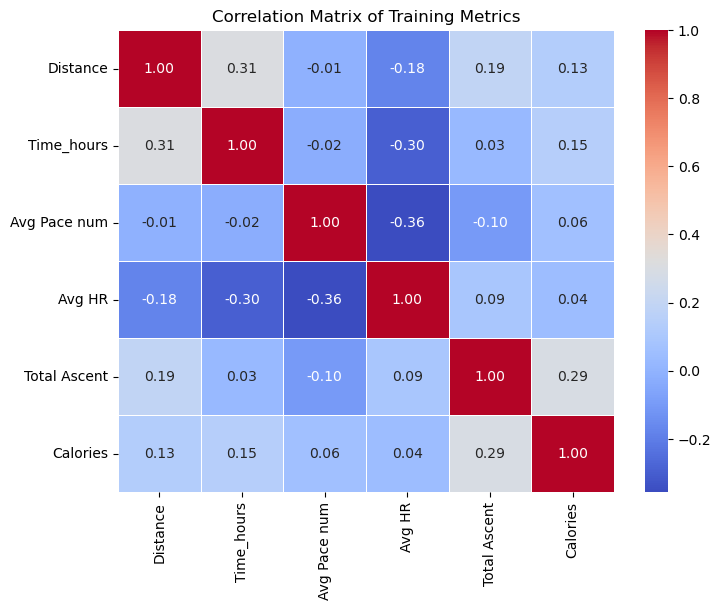

In [12]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidth=0.5
)
plt.title("Correlation Matrix of Training Metrics")
plt.savefig("../images/CorrelationMatrix_of_TrainingMetrics.png", dpi=300, bbox_inches="tight")
plt.show()

Correlation Matrix 
("Distance", "Time_hours", "Avg Pace num", "Avg HR", "Total Ascent", "Calories"):

- 0.31 - Distance та Time_hours - помірний позитивний зв’язок
- 0.29 - Total Ascent та Calories - слабкий позитивний зв’язок
- 0.19 - Distance та Total Ascent - слабкий позитивний зв’язок
- 0.15 - Time_hours та Calories - дуже слабкий або відсутній
- 0.13 - Distance та Calories  - дуже слабкий або відсутній
- 0.09 - Avg HR та Total Ascent - дуже слабкий або відсутній
- 0.06 - Avg Pace num та Calories  - дуже слабкий або відсутній
- 0.04 - Avg HR та  та Calories - дуже слабкий або відсутній
- 0.03 - Time_hours та Total Ascent  - дуже слабкий або відсутній
- -0.01 - Distance та Avg Pace num - дуже слабкий або відсутній негативний зв’язок
- -0.02 - Avg Pace num та Time_hours - дуже слабкий або відсутній негативний зв’язок
- -0.10 - Avg Pace num та Total Ascent - слабкий або відсутній негативний зв’язок
- -0.18 - Distance та Avg HR - слабкий або відсутній
- -0.30 - Time_hours та Avg HR - помірний негативний зв’язок
- -0.36 - Avg Pace num та Avg HR - помірний негативний зв’язок



Коротко - значення близькі до +1 говорять що ці змінні схильні зростати разом, якщо ближче до -1 одна зі змінних буде зростати, а інша зменшуватись, і якщо значення близьке до 0 то між цими змінними нема лінійної залежності.

Але. Всі в нашому дослідженні Avg Pace num, Avg HR, Calories пов'язані не лише з фізичною підготовкою, але і залежать від рельєфу, набору висоти, складності орієнтування.

Зокрема, маємо кореляцію -0.36 між Avg HR та Avg Pace num - зв’язок слабкий, бо на Avg HR має вплив також і Total Ascent, рельєф загалом, складність орієнтування, спека чи важливість старту.

---

#### 6. Does higher elevation gain slow down pace — and does this differ by athlete profile?

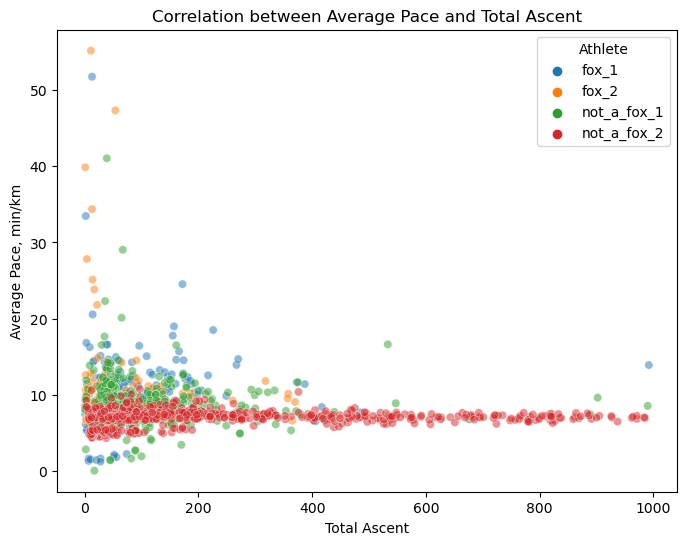

In [13]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data = df_combined, 
            x="Total Ascent", 
            y="Avg Pace num",
            hue="Athlete",
            alpha=0.5
)
plt.title("Correlation between Average Pace and Total Ascent")
plt.xlabel("Total Ascent")
plt.ylabel("Average Pace, min/km")

plt.savefig("../images/CorrelationAvgPace_TotalAscent.png", dpi=300, bbox_inches="tight")
plt.show()

Як ми вже припустили - not_a_fox_2 житель гірської місцевості, звик бігати з великим набором висоти і тут бачимо що його темп дійсно є стабільним, навіть за умови сильного підйому. В той же час fox_1 і fox_2 мають помітні викиди і без набору висоти  - Avg Pace >20 min/km, це якраз навігаційні активності — рельєф малий, але темп непередбачуваний. ARDF, орієнтування -це спершу пошук, читання карти  і вже потім швидкість. Так ми ще раз стикаємось з тим самим Beyond Pace у нашому дослідженні.

---

#### 7. Is pace alone sufficient to evaluate athletic performance — what does Pace vs HR reveal?

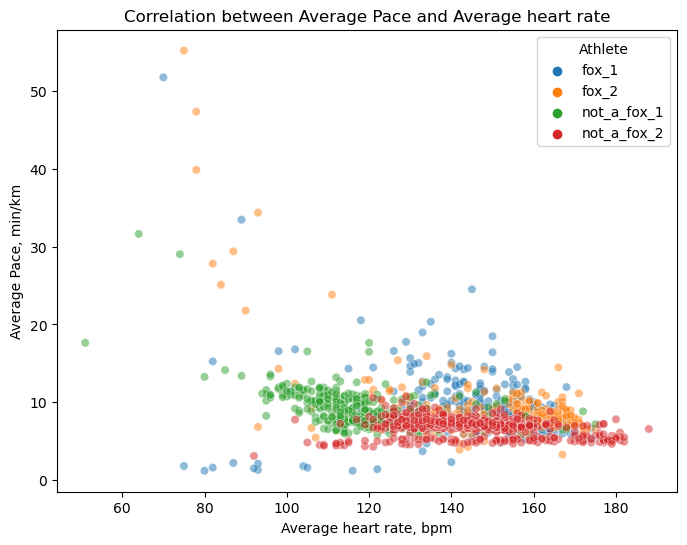

In [14]:
# Pace vs HR scatter — чи підтверджує кореляцію візуально

plt.figure(figsize=(8, 6))

sns.scatterplot(data = df_combined, 
            x="Avg HR", 
            y="Avg Pace num",
            hue="Athlete",
            alpha=0.5
)
plt.title("Correlation between Average Pace and Average heart rate")
plt.xlabel("Average heart rate, bpm")
plt.ylabel("Average Pace, min/km")

plt.savefig("../images/CorrelationAvgPace_AvgHR.png", dpi=300, bbox_inches="tight")
plt.show()

Бачимо,що для not_a_fox_2 високий HR відповідає високому темпу. У not_a_fox_1 знов бачимо найнижчий пульс при середньому темпі.
 І на противагу цьому - для fox_1, fox_2 при будь-якому пульсі розкид Pace є великим і непердбачуваним. Ми знов маємо наочну демонстрацію navigation effect.

In [15]:
df_combined["Activity Type"].value_counts()

Activity Type
Running              1605
Trail Running         145
Other                  80
Treadmill Running      36
Indoor Running         10
Name: count, dtype: int64

---

#### 8. How does training volume change over time — is there seasonal patterns in navigation-driven sports?

Щомісячний кілометраж для кожного атлета:

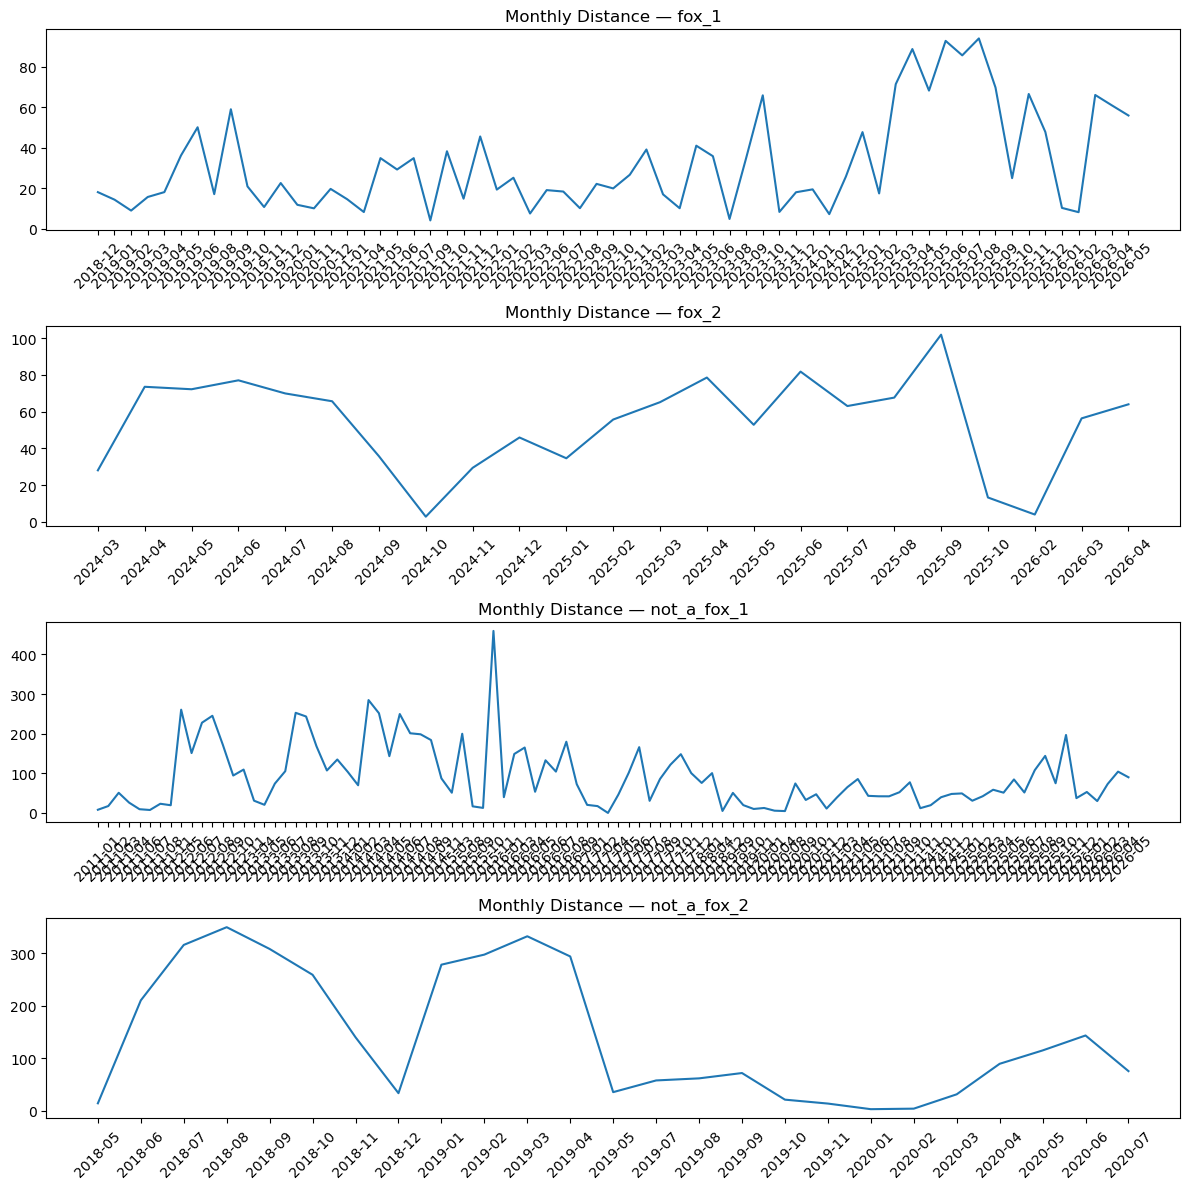

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
athletes = ["fox_1", "fox_2", "not_a_fox_1", "not_a_fox_2"]


for i in range(4):
    df_athlete = df_combined[df_combined["Athlete"] == athletes[i]].copy()
    df_athlete["YearMonth"] = df_athlete["Date"].dt.to_period("M").astype(str)
    monthly = df_athlete.groupby("YearMonth")["Distance"].sum().reset_index()
    axes[i].plot(monthly["YearMonth"], monthly["Distance"])
    axes[i].set_title(f"Monthly Distance — {athletes[i]}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../images/MonthlyDistance_byAthlete.png", dpi=300, bbox_inches="tight")
plt.show()

Почнемо з fox_2 - на графіку період в 2 роки, де легко читаються піки активності у серпні, з поступовим нарощенням напередодні, і подальшим спадом, що відповідає завершенню змагального сезону. 2 зимові періоди зовсім не схожі між собою, скоріше за все це повязано з наявністю/відсутністю снігу в різні роки. Це також один з наших navigation effects - сліди на снігу унеможливлюють тренування, є також і технічна сторона - робота приймачів/передавачів в умовах вологості та низьких температур.

Графік для fox_1 покриває тривалий часовий проміжок, тому читається складніше, деталі легко пропустити. Але вже знаючи патерн по графіку fox_2 - можна відстежити таку ж "зимову сплячку", і весняно-літні піки. Але тут бачимо і осінні піки - можливо, це типово бігові патерни закінчення бігового ссезону в жовтні-листопаді, марафони, можливо більше орієнтування, аніж ARDF, там теж сезон триває довше. Помітно також, що fox_1 має чимало пропусків з записах - від 1 до 10 місяців.

історичні показники для not_a_fox_1 умовно показують  активність близьку до 300 в першій половині спостережень, маючи пік осінню 2015року.
друга половина спостережень вжене піднімаються більше 100 км до 2025 року, і знов зростає до 200 протягом 2026. можливо атлет переживав тривале відновлення після травми.

Графік для not_a_fox_2 відображає 2річний період. Перший рік значно активніший. Обидва мають різдвяний спад, весняно-літній підйом. Між першим та другим роком перелам надзвичайно різкий - це якісь життєві обставини, можливо навіть травма, за якою слідує тривале і повільне повернення в форму.

---

### SUMMARY STATISTICS:

#### Aggregations:

#### 9. How consistent is pace across athlete profiles — and what does variability reveal about activity type?

In [17]:
# середні показники по кожному атлету:

df_combined.groupby("Athlete")[["Distance", "Avg Pace num", "Avg HR", "Total Ascent"]].mean().round(2)

,Distance,Avg Pace num,Avg HR,Total Ascent
Athlete,,,,
fox_1,6.87,9.30,146.87,72.89
fox_2,4.49,9.20,148.66,68.27
not_a_fox_1,14.63,8.44,117.17,84.46
not_a_fox_2,5.21,6.87,144.26,245.31


Найдовші середні дистанції показує fox_1    =6.87,
Найкращий темп у not_a_fox_2  Avg Pace num = 6.87,
Найспокійніший пульс  теж у not_a_fox_2 Avg HR =144.26
Найбільший набір висоти теж у not_a_fox_2 Total Ascent =245.31

Beyond Pace інтерпретація:
Для navigation driven sports чим коротша дистанція - тим оптимальніший шлях ти обрав. З набором висоти нема однозначної інтерпретації - іноді варто уникати перепадів висот аби зберегти сили, а часом ривок навпростець принесе перемогу. Темп, і пульс  зазвичай не бувають стабільними, через постійну зміну патерну руху, іноді треба вчитатись в карту - ледь не повністю зупинившись, іноді правильно зчитати рельєф, скинувши швидкість, іноді - подолати крутий підйом майже навкарачки (scramble up) чи перейти болото.

Тож те що ми звикли сприймати як краще, іноді не відповідає дійсності. Завжди важливий контекст. Як бачимо, порівнювати за одною шкалою результати класичних бігунів та  navigation driven спортсменів - безглуздо.

In [18]:
# загальна статистика по дистанції:

df_combined.groupby("Athlete")["Distance"].agg(["sum", "max", "count"]).round(2)

,sum,max,count
Athlete,,,
fox_1,2026.73,36.86,295
fox_2,1239.40,15.55,276
not_a_fox_1,9102.25,110.64,622
not_a_fox_2,3552.63,18.01,682


sum — загальна сума км за весь час
max — найдовша одна активність
count — кількість записаних активностей

НАйбільша сума набіганих км - у not_a_fox_1. 
Найбільша кількістю пробіжок - у not_a_fox_2.
Максимальний кілометраж  - not_a_fox_1.

Цікаво, що в записах not_a_fox_2 переважно дуже короткі дистанції, але записи майже щоденні - за рахунок цього він набігає великий місячний кілометраж. Сила маленьких кроків в дії.

not_a_fox_1 має тривалішу історія спостережень, за рахунок чого показує сумарну кількість пробіжок близьку до щоденних активностей  not_a_fox_2.



In [19]:
# стандартне відхилення темпу:

df_pace = df_combined[
    (df_combined["Avg Pace num"] > 0) & 
    (df_combined["Distance"] > 0)
]

df_pace.groupby("Athlete")["Avg Pace num"].agg(["min", "max", "mean", "std"]).round(2)

,min,max,mean,std
Athlete,,,,
fox_1,1.20,51.77,9.30,4.47
fox_2,3.28,55.18,9.20,5.28
not_a_fox_1,1.40,41.05,8.49,2.86
not_a_fox_2,4.28,10.73,6.88,1.05


Як видно, std у not_a_fox_2	= 1.06. Його темп дуже стабільний, майже незмінний, 6-7 хв/км.
Слідом за ним not_a_fox_1 також показує доволі стабільнгий темп.

А от у fox_1 і fox_2 std = 4.5 та 5.3 - дуже значний розкид! І min, max це теж демонструють - від 1.2 до 55 хв/км! Ось наступне відображення navigation effect в даних - атлет може мчати як вітер, а наступної миті ледь не стояти на місці оцінюючи ситуацію. 

Цей блок дослідження _____

___

### ML - > file 03_ml.ipynb